# 3 · Híbridos (AE-latente + IForest) y scoring alternativo

Probamos combinar lo mejor de cada mundo y scorings alternativos al MSE
promedio. **Todos quedaron por debajo del base** — útil para justificar el modelo
final por descarte.

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## Híbrido AE+IForest y scoring max/top-k (soja, panel union)

In [2]:
explib.show(explib.tbl_hybrids())

,modelo,soja_pr,nota
0,VAE recon_prob (referencia),0.435,el mejor single en su momento
1,AE-latente + IForest (híbrido),0.307,el latente del AE destruye la señal
2,AE score=max,0.329,max error por feature
3,AE score=topk5,0.303,suma top-5 errores


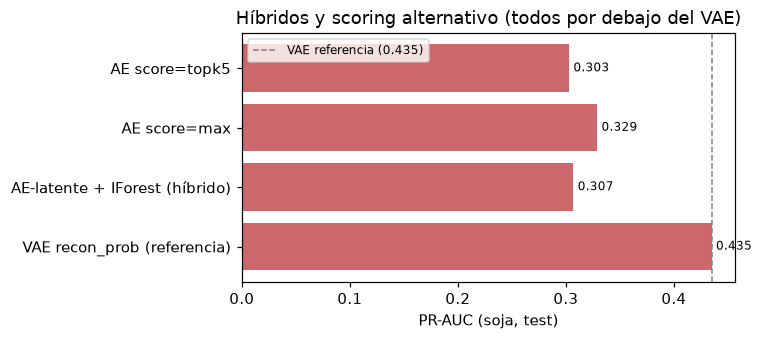

In [3]:
t = explib.tbl_hybrids()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(t["modelo"], t["soja_pr"], color="#C44E52", alpha=0.85)
for i, v in enumerate(t["soja_pr"]): ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8)
ax.axvline(0.435, ls="--", color="gray", lw=1, label="VAE referencia (0.435)")
ax.set_xlabel("PR-AUC (soja, test)"); ax.legend(fontsize=8)
ax.set_title("Híbridos y scoring alternativo (todos por debajo del VAE)")
plt.tight_layout(); plt.show()

- **AE-latente + IForest**: correr IForest sobre el latente del AE (en vez del
  espacio original). En la literatura suele ganar, pero acá **el bottleneck del AE
  destruye la estructura** que el IForest necesita → 0.307, peor que ambos por
  separado.
- **score=max / top-k**: la señal **no** se diluía en el promedio MSE; el cuello de
  botella del AE era otro (el recon_prob del VAE, no el agregador).

El tuning de `max_features` (0.3–0.5) sí hizo al **IForest** un baseline fuerte
(0.51), pero ninguno de estos enfoques superó al VAE.